# Self-supervised denoising of low-dose electron diffraction

Every Noise2-something method tried on this data, with squared error and with
the Poisson likelihood, scored identically, ending in the orientation map the
whole exercise is for.

The pipeline that produced the results is 153 numbered scripts. That is a
research log, not a protocol: most steps are controls that failed, arms that
were abandoned, or results later superseded. What actually survives is the
dozen operations below.

**The problem.** Cellulose in the plant cell wall is destroyed by the dose
needed for a clean diffraction pattern. These scans were taken at 4.5 e/A2,
below that limit, so no clean image exists and none can be acquired. We have
two exposures of the same 2400 positions, both noisy.

In [1]:
import os, sys, time
import numpy as np, torch, h5py
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates, gaussian_filter
from matplotlib.collections import LineCollection
import matplotlib.colors as mc

ROOT = r"D:\SU\Cellulose\denoise"
sys.path.insert(0, ROOT); sys.path.insert(0, os.path.join(ROOT, "pipeline"))
from step95_n2n import Net, even_project, to_polar, DEV, CROP, RMIN, NR, NTH
from step103_dose_series import polar_all, nrm
from celldenoise.single_frame import PatternGeometry
import step117_method_comparison as M
import step136_poisson_loss as P36
import step116_ensemble as E

PRE = os.path.join(ROOT, "preprocessed")
H, W = 50, 48
from IPython.display import Image, display
FIGDIR = os.path.join(ROOT, "figures", "notebook"); os.makedirs(FIGDIR, exist_ok=True)
def show(fig, name):
    "Save and embed - the pipeline modules force the Agg backend on import."
    p = os.path.join(FIGDIR, name + ".png")
    fig.savefig(p, dpi=110, bbox_inches="tight"); plt.close(fig); display(Image(p))
print("device:", DEV)

device: cuda


## 1. Preprocessing

Six operations, all of which silently corrupted an earlier analysis when they
were wrong.

| | why |
|---|---|
| chip-gap correction | the Timepix3 is four chips read out as a dense 512x512; uncorrected, radii across the seam are short by up to 4 px |
| flyback removal | 12% of frames are taken while the beam races back; they produced the strongest apparent reflection in the dataset |
| integer recentring | never interpolation - bilinear shifting drives per-pixel variance below Poisson and breaks every noise estimate downstream |
| seam inpainting | per frame, because the gap moves relative to the pattern |
| polar unroll, r in [36,104) | rotation becomes translation, and **this is what excludes the direct beam** - 57% of all counts sit inside r=36 and are never sampled |
| flattening | below |

`polar_all` does the last three. Everything before it is baked into
`scan01_clean.h5`.

stack (2400, 68, 180)  mean 3.53 counts/px  max 21


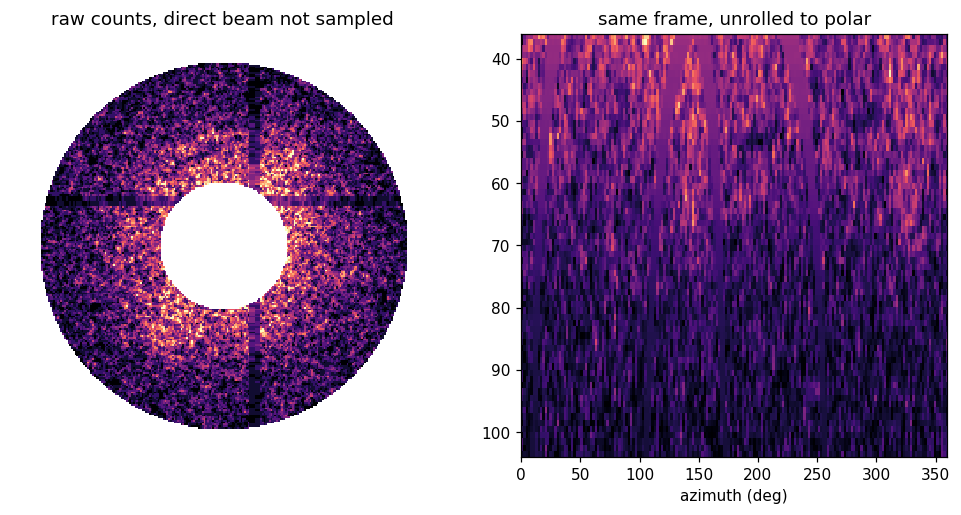

In [2]:
rawA = polar_all("scan01").astype(np.float32)   # scan 1, unflattened counts
rawB = polar_all("scan02").astype(np.float32)   # scan 2, same positions
print("stack", rawA.shape, " mean %.2f counts/px  max %.0f" % (rawA.mean(), rawA.max()))

with h5py.File(os.path.join(PRE, "scan01_clean.h5"), "r") as f:
    CY, CX = float(f.attrs["ref_cy"]), float(f.attrs["ref_cx"])
    frame0 = f["frames"][138, int(CY)-CROP:int(CY)+CROP, int(CX)-CROP:int(CX)+CROP].astype(float)

yy, xx = np.mgrid[0:2*CROP, 0:2*CROP]
rd = np.hypot(yy-CROP, xx-CROP)
ang = np.rad2deg(np.arctan2(xx-CROP, yy-CROP)) % 360
ANN = (rd >= RMIN) & (rd < RMIN+NR)

def cart(p):
    "polar (68,180) back to the detector square"
    im = map_coordinates(p, [np.clip(rd-RMIN, 0, NR-1.001), (ang/(360.0/NTH)) % NTH],
                         order=1, mode="grid-wrap")
    return np.where(ANN, im, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(np.where(ANN, frame0, np.nan), cmap="magma", vmin=0,
             vmax=np.nanpercentile(frame0[ANN], 99.5), interpolation="nearest")
ax[0].set_title("raw counts, direct beam not sampled"); ax[0].axis("off")
ax[1].imshow(rawA[138], cmap="magma", aspect="auto",
             extent=[0, 360, RMIN+NR, RMIN], interpolation="nearest")
ax[1].set_title("same frame, unrolled to polar"); ax[1].set_xlabel("azimuth (deg)")
show(fig, "01_preprocessing")


## 2. Flattening, and why it is not denoising

`nrm` is two lines:

```python
Y = X - np.median(X, axis=2, keepdims=True)   # per-radius azimuthal median
Y / Y.std(axis=(1,2), keepdims=True)          # per-frame scale
```

It removes **98% of the mean intensity** - the radial profile I(r), which is
nearly identical in every frame and carries no orientation. Its spread across
frames at fixed radius is 0.147 counts, against 1.60 across radius.

It removes **essentially no noise**: per-pixel variance falls 0.91%, and the
theoretical value for subtracting a median of 180 samples is 0.87%. So this is
background subtraction, not denoising.

It is nevertheless essential. Trained on unflattened data, the ring correlation
is 0.72 against the matched exposure **and 0.72 against a shuffled one** -
identical, therefore meaningless. The network learns the radial profile, which
every frame shares.

In [3]:
A, B = nrm(rawA), nrm(rawB)
X = rawA[:600].astype(np.float64)
med = np.median(X, axis=2, keepdims=True)
print("variance change from the median subtraction: %+.2f%%" %
      (100*((X-med).var(0).mean()/X.var(0).mean() - 1)))
print("theory for a median of %d samples          : %+.2f%%" % (NTH, -100*1.253**2/NTH))
print("mean removed: %.2f counts = %.0f%% of the mean" % (med.mean(), 100*med.mean()/X.mean()))

variance change from the median subtraction: -0.91%
theory for a median of 180 samples          : -0.87%
mean removed: 3.45 counts = 98% of the mean


## 3. Why two noisy images are enough

`A = s + nA`, `B = s + nB`, `s` the truth and never available. Train `f` to
predict B from A under squared error:

```
( f - B )^2  =  ( f - s )^2  -  2 ( f - s ) nB  +  nB^2
```

- the **cross term** averages to zero *provided nB is independent of A* -
  nothing learned from A helps predict nB, so guessing it is punished;
- the **constant** `nB^2` holds no network parameters, so its gradient is
  exactly zero and backpropagation never sees it.

What is left is the supervised loss. Minimising against a noisy target gives
the **same** `f` as minimising against a clean one.

Two caveats that matter later:

- only the **target's** noise averages away. The input's does not, so
  `f(A) -> E[s|A]`, a smoothed estimate, not `s`. This is why weak frames still
  return a plausible peak.
- the loss never reaches zero. On this data the `nB^2` floor is 97% of the final
  value, so a nearly flat training curve is correct behaviour.

## 4. Where the pairs come from - four answers

| method | target | needs |
|---|---|---|
| N2N scan-to-scan | a separate exposure | two acquisitions |
| N2N binomial | the other half of the same exposure | one |
| Noise2Void | the masked pixel's own value | one |
| Noise2Self | a grid partition of the same image | one |

**Binomial splitting** rests on Poisson thinning: for `N ~ Poisson(lam)`, dealing
each count by a coin flip gives `N1, N2 ~ Poisson(lam/2)` that are
**independent**, even though `N1 + N2 = N`.

The order matters. Thinning is exact only for **integer** counts, and 95.6% of
the polar stack is non-integer because it is an interpolation. So the split must
happen on the detector counts, before the unroll. Getting this wrong costs 25%.

## 4b. The blind-spot family: how Noise2Void and Noise2Self actually work

The table above gives each method one line. The two blind-spot entries deserve
more, because they are the ones with a **hyperparameter to get wrong**.

### The principle both share: J-invariance

N2N needs a second measurement. The blind-spot methods remove that requirement
by making the network predict a pixel it is **not allowed to see**.

Partition the pixels into sets. Call a function `f` **J-invariant** if its
output on set `J` never depends on the input values *in* `J`. For such an `f`,
if the noise is independent between pixels and has zero mean, the self-
prediction error splits exactly:

```
E|| f(x) - x ||^2   =   E|| f(x) - s ||^2   +   E|| x - s ||^2
   (measurable)          (what we want)       (no parameters -> zero gradient)
```

The last term is the noise variance; it contains no network parameters, so
backpropagation never sees it. Therefore **minimising the noisy image's ability
to predict itself minimises the true error** - supervision from one image, no
pair required. (Batson & Royer 2019; Krull et al. 2019 for N2V.)

Note the premise, because everything below turns on it: *noise independent
between pixels*. Break it and the network simply reads a masked pixel's value
off its neighbours.

### Noise2Void - mask a random subset

In this notebook: `neighbour_swap(x, frac=param)`, with `param = 0.20`.

- Draw a random `frac` of the pixels. Replace each one with a **neighbouring**
  pixel's value, so the network cannot see the true centre value.
- Compute the loss **only at those pixels**, against their original values:
  `((lam - x*log(lam)) * m).sum() / m.sum()`.
- The blind spot is manufactured by **corrupting the input**, not by the
  architecture. It holds only in expectation, over many random draws.

### Noise2Self - mask a deterministic grid

In this notebook: `grid_mask(x, stride=param)`, with `param = 2`.

- Take every `stride`-th pixel in each direction as one partition (stride 2 =
  one pixel in four). Mask that whole partition at once and predict it from the
  rest.
- Because the partition is **deterministic**, J-invariance holds exactly rather
  than on average, which is the theoretical tidiness N2S buys over N2V.

### How they differ

| | Noise2Void | Noise2Self |
|---|---|---|
| masked set | random subset, redrawn every step | fixed grid partition |
| how the pixel is hidden | overwritten with a neighbour's value | held out of the input |
| J-invariance | approximate (in expectation) | exact by construction |
| main risk | the replacement value is *correlated* with the true one, so the blind spot leaks | fewer supervised pixels per pass |

### They both need a parameter. Binomial does not.

This is the practical point:

| method | parameter | what it trades off |
|---|---|---|
| Noise2Void | masking fraction `frac` (0.20 here) | too small -> few supervised pixels per pass, slow and noisy gradients; too large -> the input is substantially corrupted, and the network is denoising a damaged image |
| Noise2Self | grid `stride` (2 here) | small stride -> many pixels held out at once (efficient), but a masked pixel's neighbours are masked too; large stride -> few pixels per pass, so more passes for the same coverage |
| N2N scan-to-scan | none | but it needs **two acquisitions** |
| **N2N binomial** | **none** | the coin is fair by construction, `p = 1/2`; Poisson thinning is exact for integer counts, and one exposure is enough |

Both blind-spot parameters also interact with the data: they assume
pixel-independent noise, and on this data that assumption is weakest exactly
where it matters. 95.6% of the polar stack is non-integer *because it is an
interpolation* - and interpolation correlates neighbouring pixels. A detector
PSF does the same. The more correlated the noise, the more a blind-spot network
can predict a masked pixel from its neighbours without learning any signal.

That asymmetry - one exposure, no hyperparameter, an exact independence
guarantee - is why the **DINO-4DSTEM GUI implements only the binomial
pairing**. There is nothing to tune and nothing to get wrong, provided you feed
it raw integer counts.

### The failure mode to watch for

If the blind spot leaks - the replacement value is correlated with the truth, or
the noise is spatially correlated - the network can drift toward the **identity**
function. It then returns a beautifully clean image that contains no information
it was not given. This is why a convincing output is never evidence, and why the
scoring in section 7 is built around a *matched vs control* comparison against an
independent exposure rather than around how good the pictures look.


In [4]:
def split_then_polar(scan, seed=0):
    "Split the INTEGER detector counts, then unroll each half separately."
    rng = np.random.default_rng(seed)
    with h5py.File(os.path.join(PRE, "%s_clean.h5" % scan), "r") as f:
        CY, CX = float(f.attrs["ref_cy"]), float(f.attrs["ref_cx"])
        cy, cx = f["centre_y"][:], f["centre_x"][:]
        n = f["frames"].shape[0]
        g = PatternGeometry(crop=CROP, seam_y=257-int(CY)+CROP,
                            seam_x=257-int(CX)+CROP, seam_half_width=3)
        P1 = np.empty((n, NR, NTH), np.float32); P2 = np.empty_like(P1)
        for i in range(n):
            k = f["frames"][i, int(CY)-CROP:int(CY)+CROP,
                            int(CX)-CROP:int(CX)+CROP].astype(np.int64)
            a = rng.binomial(k, 0.5); b = k - a
            sh = (int(round(CY-cy[i])), int(round(CX-cx[i])))
            P1[i] = to_polar(g.inpaint(a.astype(float), sh))
            P2[i] = to_polar(g.inpaint(b.astype(float), sh))
    return P1, P2

C1, C2 = split_then_polar("scan01")
print("non-integer fraction, polar stack (wrong place to split): %.1f%%" %
      (100*np.mean(np.abs(rawA-np.round(rawA)) > 1e-6)))

non-integer fraction, polar stack (wrong place to split): 95.8%


## 5. The network

18,849 parameters. Three 3x3 convolutions of 32 channels with GELU, then a 1x1
to one output channel. No downsampling, no skip connections, no pretrained
weights - not a U-Net, not a ResNet, trained from scratch in under a minute.

The size is a constraint, not a limitation. The receptive field is 7x7 and a
reflection spans about 5x5. A network that could see further could memorise
structure common to every frame and reproduce it regardless of input - which is
exactly the failure the controls below are built to catch.

Two departures from a generic CNN encode physics:

- **circular padding in azimuth**, because 359 deg is next to 0 deg;
- **even-harmonic projection** on the output. Friedel's law makes the pattern
  centrosymmetric, so `I(theta)` has period 180 and only even harmonics are
  physically possible. Note this is exactly a fold of theta onto theta+180 - it
  is *not* a low-pass filter and cannot cause ringing.

In [5]:
rng = np.random.default_rng(0)
perm = rng.permutation(len(A)); tr, va = perm[:1920], perm[1920:]
phi_fit = np.load(os.path.join(PRE, "step48_selection.npz"))["phi"]

# the control: a position whose fibril orientation differs by more than 45 deg.
# Positions drawn at RANDOM are not independent - fibrils are aligned over long
# distances, median |dphi| between two random positions is only 9.9 deg.
Dm = M.dphi(phi_fit[va][:, None], phi_fit[va][None, :])
ctrl = np.array([int(rng.choice(np.flatnonzero(Dm[k] > 45))) for k in range(len(va))])
print("held-out %d, every one has a control partner >45 deg away" % len(va))

held-out 480, every one has a control partner >45 deg away


## 6. Train all four, with squared error and with the Poisson likelihood

**Why Poisson.** MSE treats every pixel as equally reliable. Poisson variance
equals the mean, so bright pixels are noisier and MSE over-weights them; the
likelihood weights each by its own expected variance. It is still a Bregman
divergence, so it is minimised by the conditional mean and the N2N argument
carries over. (L1 would **not** - it converges to the median, biased for skewed
counts.)

The practical consequence: MSE needs the data flattened *before* the loss,
Poisson does not, and the Poisson output stays a rate in counts.

In [6]:
def train_poisson(kind, X, Y=None, param=None, seed=0, epochs=30):
    torch.manual_seed(seed); net = Net().to(DEV)
    opt = torch.optim.Adam(net.parameters(), 2e-3)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    tx = torch.tensor(X).unsqueeze(1)
    ty = torch.tensor(Y).unsqueeze(1) if Y is not None else None
    for ep in range(epochs):
        net.train(); p = torch.randperm(len(tx))
        for i in range(0, len(tx), 32):
            j = p[i:i+32]; x = tx[j].to(DEV)
            sh = int(torch.randint(0, NTH, (1,))); x = torch.roll(x, sh, -1)
            if kind == "pair":
                y = torch.roll(ty[j].to(DEV), sh, -1)
                lam = P36.rate(net, x); loss = (lam - y*torch.log(lam)).mean()
            else:
                xin, m = (M.neighbour_swap(x, frac=param) if kind == "n2v"
                          else M.grid_mask(x, stride=param))
                lam = P36.rate(net, xin)
                loss = ((lam - x*torch.log(lam))*m).sum()/m.sum().clamp_min(1)
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()
    net.eval(); return net

t0 = time.time()
mse_nets = {
    "N2N scan-to-scan": M.train("pair", A[tr], B[tr], seed=0),
    "N2N binomial":     M.train("pair", nrm(C1)[tr], nrm(C2)[tr], seed=0),
    "Noise2Void":       M.train("n2v", A[tr], None, seed=0),
    "Noise2Self":       M.train("n2s", A[tr], None, seed=0),
}
poi_nets = {
    "N2N scan-to-scan": train_poisson("pair", rawA[tr], rawB[tr]),
    "N2N binomial":     train_poisson("pair", C1[tr], C2[tr]),
    "Noise2Void":       train_poisson("n2v", rawA[tr], param=0.20),
    "Noise2Self":       train_poisson("n2s", rawA[tr], param=2),
}
print("trained 8 networks in %.1f min" % ((time.time()-t0)/60))

trained 8 networks in 2.0 min


## 7. Scoring

Three numbers, all on the same held-out positions.

- **specificity** - ring correlation against the matched independent exposure,
  minus the same against the control. This is the one that matters: it asks
  whether the output carries *position-specific* information.
- **orientation agreement** - does scan 1 and scan 2 give the same angle to
  within 20 deg? Never touches the training targets.
- **fabrication** - how often a synthetic peak *known to be single* comes out
  split. Pure invention; lower is better.

In [7]:
def score(net, poisson):
    P = nrm(P36.predict_rate(net, rawA[va])) if poisson else M.predict(net, A[va])
    Q = nrm(P36.predict_rate(net, rawB[va])) if poisson else M.predict(net, B[va])
    gap = float(np.median(M.ring(P, B[va])) - np.median(M.ring(P, B[va][ctrl])))
    ag = float(np.mean(M.dphi(np.array([M.orient(p) for p in P]),
                              np.array([M.orient(p) for p in Q])) < 20))
    r = np.random.default_rng(7)
    art = np.mean([E.is_split(
        (nrm(P36.rate(net, torch.tensor(E.synth(16, .5, r)[None, None]).to(DEV)
             ).detach().cpu().numpy()[0])[0] if poisson else
         even_project(net(torch.tensor(E.synth(16, .5, r)[None, None]).to(DEV))
             ).detach().cpu().numpy()[0, 0])) for _ in range(60)])
    return gap, ag, art

rows = []
for loss, nets, poi in (("MSE", mse_nets, False), ("Poisson", poi_nets, True)):
    for lab, net in nets.items():
        g, ag, art = score(net, poi)
        rows.append((lab, loss, g, ag, art))
g0 = float(np.median(M.ring(A[va], B[va])) - np.median(M.ring(A[va], B[va][ctrl])))

print("%-20s %-8s %8s %8s %10s" % ("method", "loss", "gap", "agree", "fabricates"))
for lab, loss, g, ag, art in sorted(rows, key=lambda r: -r[2]):
    print("%-20s %-8s %8.4f %7.0f%% %9.0f%%" % (lab, loss, g, 100*ag, 100*art))
print("%-20s %-8s %8.4f" % ("no network", "-", g0))

method               loss          gap    agree fabricates
N2N scan-to-scan     MSE        0.1187      92%        58%
N2N scan-to-scan     Poisson    0.1105      89%        43%
N2N binomial         Poisson    0.0811      88%       100%
N2N binomial         MSE        0.0778      89%        98%
Noise2Void           Poisson    0.0683      88%       100%
Noise2Void           MSE        0.0567      87%       100%
Noise2Self           Poisson    0.0522      87%        98%
Noise2Self           MSE        0.0409      86%       100%
no network           -          0.0394


## 8. What the frames look like

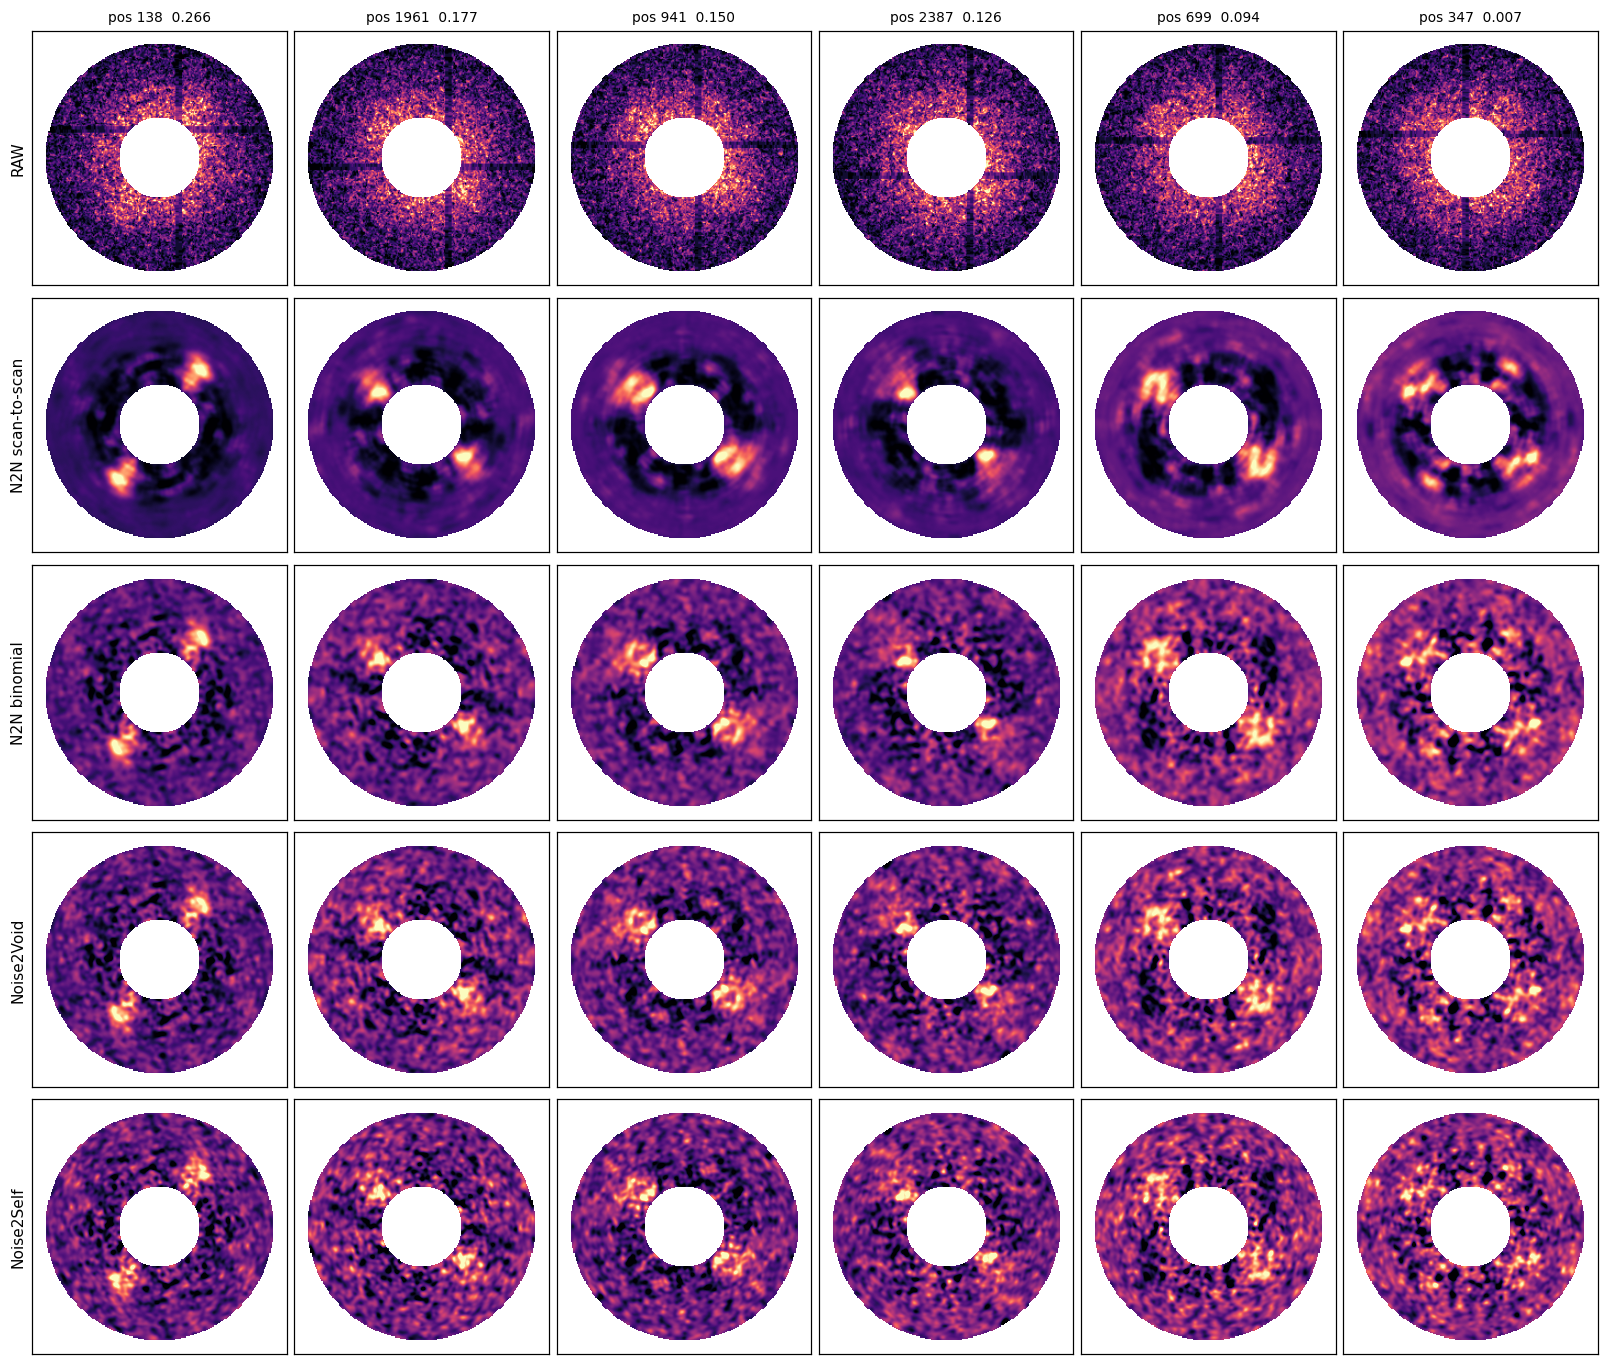

In [8]:
pick = [138, 1961, 941, 2387, 699, 347]      # best to worst by peak score
sc = np.load(os.path.join(PRE, "step99_two_methods.npz"))["scan12"]
with h5py.File(os.path.join(PRE, "scan01_clean.h5"), "r") as f:
    fr = f["frames"][sorted(pick), int(CY)-CROP:int(CY)+CROP,
                     int(CX)-CROP:int(CX)+CROP].astype(float)
fm = {i: fr[k] for k, i in enumerate(sorted(pick))}

ROWS = [("RAW", None, False)] + [(k, v, False) for k, v in mse_nets.items()]
fig, ax = plt.subplots(len(ROWS), 6, figsize=(15, 2.5*len(ROWS)))
for c, i in enumerate(pick):
    for r, (lab, net, poi) in enumerate(ROWS):
        a = ax[r, c]
        if net is None:
            v = np.where(ANN, fm[i], np.nan); lo, hi = 0, np.nanpercentile(v, 99.5)
        else:
            with torch.no_grad():
                o = even_project(net(torch.tensor(A[i][None, None]).to(DEV))).cpu().numpy()[0, 0]
            v = np.where(ANN, gaussian_filter(np.nan_to_num(cart(o)), 1.2), np.nan)
            lo, hi = np.nanpercentile(v, [2, 99.6])
        a.imshow(v, cmap="magma", vmin=lo, vmax=hi, interpolation="bilinear")
        a.set_xticks([]); a.set_yticks([]); a.set_xlim(4, 2*CROP-4); a.set_ylim(2*CROP-4, 4)
        if r == 0: a.set_title("pos %d  %.3f" % (i, sc[i]), fontsize=9)
        if c == 0: a.set_ylabel(lab, fontsize=10)
fig.subplots_adjust(left=.05, right=.999, top=.97, bottom=.004, wspace=.03, hspace=.03)
show(fig, "02_frames_all_methods")


## 9. Does it help the measurement, or only the picture?

The trap: a network that pushes every frame toward the domain mean improves
precision **and** spatial coherence while adding nothing. So the spread must be
checked too - within domain, since the global spread is dominated by the two
domains sitting 81 deg apart and would hide a collapse.

In [9]:
def orientations(net, poisson=False):
    P = nrm(P36.predict_rate(net, rawA)) if poisson else (
        M.predict(net, A) if net is not None else A)
    Q = nrm(P36.predict_rate(net, rawB)) if poisson else (
        M.predict(net, B) if net is not None else B)
    return (np.array([M.orient(p) for p in P]),
            np.array([M.orient(p) for p in Q]))

dom = np.load(os.path.join(PRE, "step76_field.npz"))["dom"].ravel()
def circ_sd(d):
    a = np.deg2rad(2*d); Rb = np.hypot(np.cos(a).mean(), np.sin(a).mean())
    return float(np.rad2deg(np.sqrt(-2*np.log(max(Rb, 1e-9))))/2)

print("%-22s %10s %10s %12s" % ("", "error(deg)", "sd domA", "neighbour"))
for lab, net in [("raw, no network", None)] + list(mse_nets.items()):
    pA, pB = orientations(net)
    err = np.median(M.dphi(pA[va], pB[va]))/np.sqrt(2)
    idx = np.arange(len(pA)); same = (idx % W) < W-1
    coh = np.median(M.dphi(pA[idx[same]], pA[idx[same]+1]))
    print("%-22s %10.1f %10.1f %12.1f" % (lab, err, circ_sd(pA[va][dom[va] == 0]), coh))

                       error(deg)    sd domA    neighbour
raw, no network               5.5       13.5          7.1


N2N scan-to-scan              3.9       13.5          5.1


N2N binomial                  4.9       13.3          6.4


Noise2Void                    5.5       13.6          6.6


Noise2Self                    5.4       13.2          7.2


Read it as: **precision improves, spread does not move.** If the spread had
collapsed the gain would be smoothing, not information.

Only scan-to-scan gives a real improvement - 5.5 to 3.9 deg. The rest sit within
noise of the raw data. A second physical exposure is worth more than any choice
of algorithm.

## 10. The result: the fibril orientation field

Each scan position is drawn as a **stick** along the fibril axis, which is the
arc azimuth minus 90 deg because (200) is perpendicular to the chain. The stick
is drawn *through* the position in both directions, since orientation is axial -
10 deg and 190 deg are the same thing. Colour cycles every 180 deg for the same
reason; a non-cyclic map would put a false seam through the field. Opacity
carries per-frame signal strength, so weak positions recede.

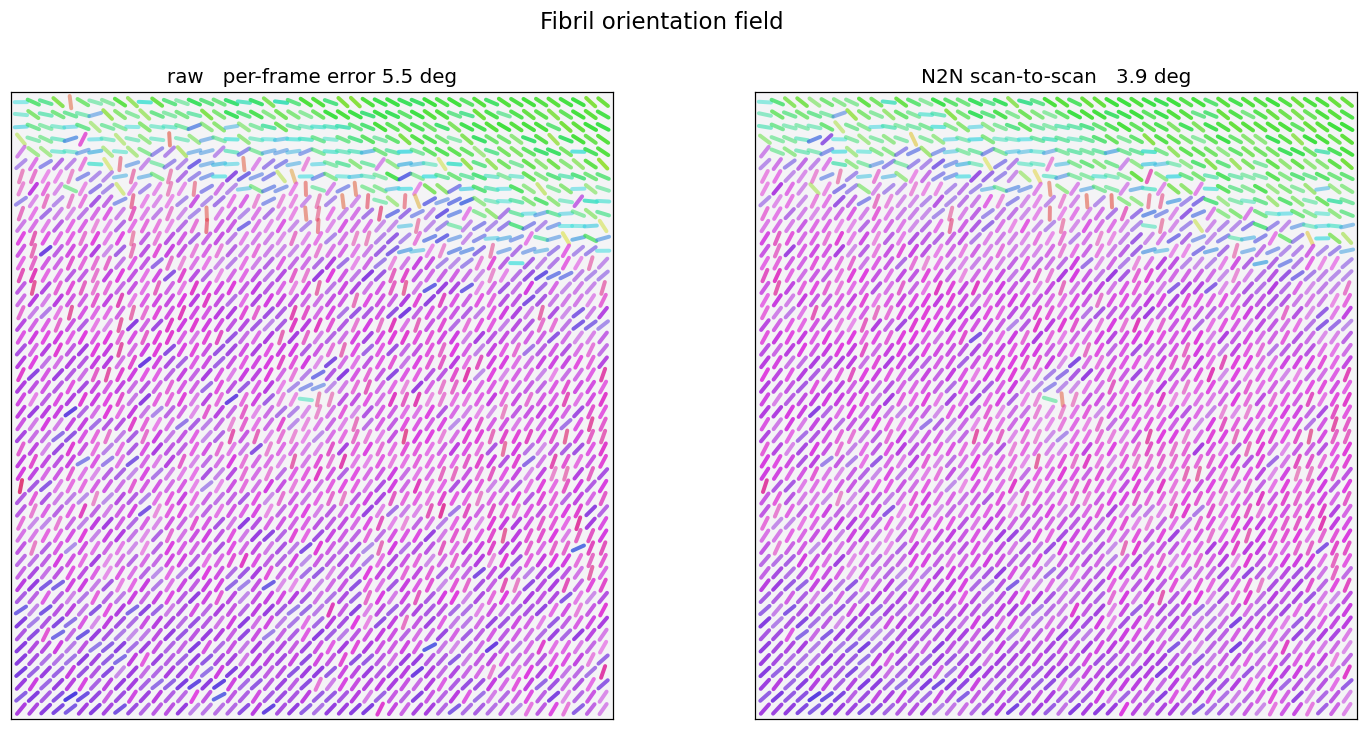

In [10]:
def stick_map(ax, phi_deg, conf, L=0.50, lw=2.6):
    yy_, xx_ = np.divmod(np.arange(H*W), W)
    t = np.deg2rad(phi_deg - 90.0)                   # fibril axis
    dx, dy = L*np.sin(t), L*np.cos(t)
    S = np.stack([np.stack([xx_-dx, yy_-dy], 1),
                  np.stack([xx_+dx, yy_+dy], 1)], 1)
    hsv = np.zeros((len(phi_deg), 3))
    hsv[:, 0] = ((phi_deg - 90.0) % 180)/180.0; hsv[:, 1] = 0.72; hsv[:, 2] = 0.88
    c = np.concatenate([mc.hsv_to_rgb(hsv), (0.55 + 0.45*conf)[:, None]], 1)
    ax.add_collection(LineCollection(S, colors=c, linewidths=lw, capstyle="round"))
    ax.set_xlim(-.8, W-.2); ax.set_ylim(H-.2, -.8); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor("#f4f4f6")

conf = np.clip((sc-np.percentile(sc, 10))/(np.percentile(sc, 90)-np.percentile(sc, 10)), 0, 1)
pR, _ = orientations(None)
pD, _ = orientations(mse_nets["N2N scan-to-scan"])

fig, ax = plt.subplots(1, 2, figsize=(16, 7.4))
stick_map(ax[0], pR, conf); ax[0].set_title("raw   per-frame error 5.5 deg", fontsize=13)
stick_map(ax[1], pD, conf); ax[1].set_title("N2N scan-to-scan   3.9 deg", fontsize=13)
fig.suptitle("Fibril orientation field", fontsize=15)
show(fig, "03_orientation_field")


## What not to believe

- **A convincing output is not evidence.** Applied to the most damaged scans the
  network still returns clean reflections from frames containing nothing. Only a
  matched comparison against an independent exposure separates recovery from
  invention.
- **Fine angular detail is fabricated.** Weak peaks emerge as doublets a few
  degrees apart, and a synthetic peak known to be single does the same. The
  network's own output noise has an azimuthal correlation halfwidth of 6 deg,
  which sets a hard resolution limit near 14 deg.
- **A threshold is still needed.** Denoising helps most where signal is weakest,
  but the weakest quintile stays ~2.5x worse than the strongest.

## For a tilt series

Two exposures at half dose each cost the same total dose as one at full dose, so
the scan-to-scan pairing is not a dose penalty - it is a choice about how to
spend dose you were already going to use. What remains untested is whether a
network trained at one tilt applies at another; transfer has only been shown
across damage state, at fixed tilt.